# 06 — Classical Models with 5-Fold Cross-Validation
## Multi-Attribute Scene Classification on nuScenes Front-Camera Images

**This is the experimental engine.** It trains five classical model families × two variants (base + tuned) × four scene attributes × three seeds **across 5 folds** of scene-aware cross-validation — totalling **600 model fits** — and saves all results for downstream analysis.

### What's new vs the previous single-split version

1. **5-fold scene-aware CV** — every scene appears in test exactly once across folds (notebook 04)
2. **Per-fold metrics** — `fold` column in `all_metrics.csv` enables aggregation downstream
3. **Aggregate metrics** — mean ± std across folds reported per (model × version × attribute)
4. **Reduced grid search** — slightly smaller grids since we're running 5× more fits
5. **All other A+ features preserved** — baselines, time tracking, HP-in-table

### The five model families

| # | Model | Family | Decision boundary |
|---|---|---|---|
| 1 | Logistic Regression | Linear / probabilistic | Hyperplane |
| 2 | SVM (RBF kernel) | Kernel-based | Curved, margin-maximising |
| 3 | Random Forest | Tree ensemble (bagging) | Axis-aligned splits, averaged |
| 4 | XGBoost | Tree ensemble (boosting) | Sequentially corrected splits |
| 5 | MLP (1-2 hidden layers) | Shallow neural network | Non-linear, fully-connected |

### Plus two trivial baselines (for context)

- **Random** baseline — predict each class with uniform probability
- **Majority-class** baseline — always predict the most-common training class

### Experimental matrix

```
5 models × 2 versions × 4 attributes × 3 seeds × 5 folds = 600 fits
+ 2 baselines × 4 attributes × 3 seeds × 5 folds = 120 baseline computations
```

### Outputs

| File | Contents |
|---|---|
| `models/fold_<k>/{attr}/{model}_{version}_seed{s}.pkl` | Pickled trained models (organized by fold) |
| `results/metrics/all_metrics.csv` | Per-fit metrics with `fold` column |
| `results/metrics/baseline_metrics.csv` | Random + majority-class baselines per fold |
| `results/metrics/aggregated_metrics.csv` | Mean ± std across folds per (model × version × attr) |
| `results/predictions/predictions_test.csv` | Per-sample test predictions with `fold` column |
| `results/figures/classical/*.png` | Confusion matrices, comparison bars |

### Runtime estimate

| Component | Time |
|---|---|
| Baselines | ~5 sec |
| Base models (300 fits, no grid search) | ~10-15 min |
| Tuned models (300 fits, grid search) | ~60-150 min |
| **Total** | **~1.5-3 hours on Ryzen 9950X3D** |


## 0. Setup

In [4]:
import os
import json
import time
import pickle
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)
import xgboost as xgb

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

print('Imports OK')

Imports OK


In [5]:
DATASET_VERSION = 'v1.0-mini'
SPLIT_DIR    = Path('data/splits')
FEATURE_DIR  = Path('data/features')
MODELS_DIR   = Path('models')
RESULTS_DIR  = Path('results/metrics')
PRED_DIR     = Path('results/predictions')
FIG_DIR      = Path('results/figures/classical')
for p in [MODELS_DIR, RESULTS_DIR, PRED_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

SEED_LIST = [42, 7, 123]

# K-fold configuration — loaded from notebook 04 metadata
with open(SPLIT_DIR / 'kfold_metadata.json') as f:
    kfold_meta = json.load(f)
N_FOLDS = kfold_meta['n_folds']
print(f'Loaded k-fold config: N_FOLDS = {N_FOLDS}')

ATTRIBUTES = ['time_of_day', 'weather', 'vehicle_density', 'vru_present']
CLASS_ORDERS = {
    'time_of_day':     ['day', 'night'],
    'weather':         ['clear', 'rain'],
    'vehicle_density': ['low', 'medium', 'high'],
    'vru_present':     ['absent', 'present'],
}
DISPLAY_NAMES = {
    'LogisticRegression': 'LogReg',
    'SVM_RBF':            'SVM',
    'RandomForest':       'RF',
    'XGBoost':            'XGB',
    'MLP':                'MLP',
}

print(f'DATASET_VERSION = {DATASET_VERSION}')
print(f'SEED_LIST       = {SEED_LIST}')
print(f'ATTRIBUTES      = {ATTRIBUTES}')

Loaded k-fold config: N_FOLDS = 5
DATASET_VERSION = v1.0-mini
SEED_LIST       = [42, 7, 123]
ATTRIBUTES      = ['time_of_day', 'weather', 'vehicle_density', 'vru_present']


## 1. Load Feature Metadata

In [6]:
with open(FEATURE_DIR / 'feature_metadata.json') as f:
    feature_meta = json.load(f)
FEATURE_COLS = feature_meta['feature_columns_all']
print(f'Feature dimensions: {len(FEATURE_COLS)}')

Feature dimensions: 6216


## 2. Helper Functions

In [7]:
def encode_labels(values, class_order):
    """Encode string labels as integers using a fixed class order."""
    label_map = {c: i for i, c in enumerate(class_order)}
    return np.array([label_map[v] for v in values], dtype=np.int64)

def metrics_dict(y_true, y_pred, num_class):
    """Compute standard classification metrics including per-class F1."""
    out = {
        'accuracy':         accuracy_score(y_true, y_pred),
        'macro_f1':         f1_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_precision':  precision_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_recall':     recall_score(y_true, y_pred, average='macro', zero_division=0),
    }
    f1_per_class = f1_score(y_true, y_pred, average=None,
                             labels=list(range(num_class)), zero_division=0)
    for i, f in enumerate(f1_per_class):
        out[f'f1_class_{i}'] = float(f)
    return out

print('Helpers defined.')

Helpers defined.


## 3. Model Definitions — Base Versions

Default sklearn / XGBoost configurations. No class weighting, no tuning.

In [8]:
def make_base_lr(seed):
    return LogisticRegression(solver='lbfgs', max_iter=1000, random_state=seed)

def make_base_svm(seed):
    return SVC(kernel='rbf', random_state=seed, probability=False)

def make_base_rf(seed):
    return RandomForestClassifier(random_state=seed, n_jobs=-1)

def make_base_xgb(seed, num_class):
    if num_class == 2:
        return xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                                  random_state=seed, n_jobs=-1, tree_method='hist',
                                  verbosity=0)
    return xgb.XGBClassifier(objective='multi:softprob', num_class=num_class,
                              eval_metric='mlogloss', random_state=seed, n_jobs=-1,
                              tree_method='hist', verbosity=0)

def make_base_mlp(seed):
    return MLPClassifier(hidden_layer_sizes=(64,), random_state=seed,
                          max_iter=500, early_stopping=False)

print('Base model factories defined.')

Base model factories defined.


## 4. Model Definitions — Tuned Versions

Grid search via 5-fold stratified CV on training data (within each outer fold), with class weighting. Grids are slightly reduced compared to single-split version since we have 5× more outer fits.

In [9]:
# Slightly reduced grids vs single-split version — still finds good config
LR_GRID  = {'C': [0.1, 1.0, 10.0]}
SVM_GRID = {'C': [1.0, 10.0], 'gamma': ['scale', 0.1]}
RF_GRID  = {'n_estimators': [200, 500], 'max_depth': [None, 20]}
XGB_GRID = {'n_estimators': [200, 500], 'max_depth': [4, 6], 'learning_rate': [0.1]}
MLP_GRID = {'hidden_layer_sizes': [(64,), (128,)], 'alpha': [1e-4, 1e-3]}

def make_tuned_lr(seed):
    base = LogisticRegression(solver='lbfgs', max_iter=2000, class_weight='balanced',
                               random_state=seed)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
    return GridSearchCV(base, LR_GRID, cv=cv, scoring='f1_macro', n_jobs=-1)

def make_tuned_svm(seed):
    base = SVC(kernel='rbf', class_weight='balanced', probability=False, random_state=seed)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
    return GridSearchCV(base, SVM_GRID, cv=cv, scoring='f1_macro', n_jobs=-1)

def make_tuned_rf(seed):
    base = RandomForestClassifier(class_weight='balanced', random_state=seed, n_jobs=-1)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
    return GridSearchCV(base, RF_GRID, cv=cv, scoring='f1_macro', n_jobs=-1)

def make_tuned_xgb(seed, num_class):
    if num_class == 2:
        base = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                                  random_state=seed, n_jobs=-1, tree_method='hist',
                                  verbosity=0)
    else:
        base = xgb.XGBClassifier(objective='multi:softprob', num_class=num_class,
                                  eval_metric='mlogloss', random_state=seed, n_jobs=-1,
                                  tree_method='hist', verbosity=0)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
    return GridSearchCV(base, XGB_GRID, cv=cv, scoring='f1_macro', n_jobs=-1)

def make_tuned_mlp(seed):
    base = MLPClassifier(random_state=seed, max_iter=500, early_stopping=True)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
    return GridSearchCV(base, MLP_GRID, cv=cv, scoring='f1_macro', n_jobs=-1)

MODEL_FACTORIES = {
    'base': {
        'LogisticRegression': lambda s, n: make_base_lr(s),
        'SVM_RBF':            lambda s, n: make_base_svm(s),
        'RandomForest':       lambda s, n: make_base_rf(s),
        'XGBoost':            lambda s, n: make_base_xgb(s, n),
        'MLP':                lambda s, n: make_base_mlp(s),
    },
    'tuned': {
        'LogisticRegression': lambda s, n: make_tuned_lr(s),
        'SVM_RBF':            lambda s, n: make_tuned_svm(s),
        'RandomForest':       lambda s, n: make_tuned_rf(s),
        'XGBoost':            lambda s, n: make_tuned_xgb(s, n),
        'MLP':                lambda s, n: make_tuned_mlp(s),
    },
}
MODEL_NAMES = list(MODEL_FACTORIES['base'].keys())
print(f'Tuned model factories defined.')
print(f'Models: {MODEL_NAMES}')

Tuned model factories defined.
Models: ['LogisticRegression', 'SVM_RBF', 'RandomForest', 'XGBoost', 'MLP']


## 5. K-Fold Training Loop

For each fold:
  1. Load `fold_<k>_train.csv` and `fold_<k>_test.csv`
  2. Fit StandardScaler on training set only
  3. Train baselines (random + majority)
  4. Train all 5 models × 2 versions × 3 seeds = 30 fits per fold per attribute
  5. Save metrics with `fold` column

Total: 5 folds × 4 attributes × 30 fits = 600 model fits.

In [10]:
def fit_and_evaluate(estimator, X_tr, X_te, y_tr, y_te, num_class,
                       attr, seed, version, model_name, fold):
    """Fit one model, time it, collect metrics. Handles edge cases."""
    t_fit = time.time()

    # Defensive: if using GridSearchCV with stratified inner CV, ensure each
    # class has at least n_splits samples. If not, fall back to base estimator.
    if hasattr(estimator, 'cv') and hasattr(estimator, 'estimator'):
        class_counts = np.bincount(y_tr, minlength=num_class)
        min_per_class = class_counts[class_counts > 0].min()
        try:
            n_splits = estimator.cv.n_splits
        except AttributeError:
            n_splits = 3
        if min_per_class < n_splits:
            # Use the inner estimator directly with default params
            estimator = estimator.estimator
            print(f'    (note: fold={fold} attr={attr} model={model_name} seed={seed}: '
                  f'min class count {min_per_class} < cv splits {n_splits}; '
                  f'using base estimator instead of grid search)')

    estimator.fit(X_tr, y_tr)
    fit_time = time.time() - t_fit

    final = estimator.best_estimator_ if hasattr(estimator, 'best_estimator_') else estimator
    best_params = estimator.best_params_ if hasattr(estimator, 'best_params_') else {}

    t_pred = time.time()
    yp_test = final.predict(X_te)
    predict_time_test = time.time() - t_pred

    yp_train = final.predict(X_tr)

    rows = []
    for split, yt, yp in [('train', y_tr, yp_train),
                          ('test',  y_te, yp_test)]:
        m = metrics_dict(yt, yp, num_class)
        m.update({'fold': fold, 'attribute': attr, 'model': model_name,
                  'version': version, 'seed': seed, 'split': split,
                  'fit_time_sec': fit_time,
                  'predict_time_test_sec': predict_time_test,
                  'best_params': json.dumps(best_params)})
        rows.append(m)

    return final, rows, yp_test

print('Fit-and-evaluate helper defined (with defensive grid-search fallback).')

Fit-and-evaluate helper defined (with defensive grid-search fallback).


In [11]:
# Main k-fold loop
all_rows = []
baseline_rows = []
all_test_predictions = []
skipped_combos = []  # Track (fold, attr) combos skipped due to single-class training

t_global_start = time.time()
print(f'Starting k-fold training: {N_FOLDS} folds × {len(ATTRIBUTES)} attrs × '
       f'{len(MODEL_NAMES)} models × 2 versions × {len(SEED_LIST)} seeds = '
       f'{N_FOLDS * len(ATTRIBUTES) * len(MODEL_NAMES) * 2 * len(SEED_LIST)} fits\n')

for fold_k in range(N_FOLDS):
    print(f'\n{"=" * 70}\nFOLD {fold_k} / {N_FOLDS - 1}\n{"=" * 70}')

    # Load this fold's train/test data
    df_train = pd.read_csv(SPLIT_DIR / f'fold_{fold_k}_train.csv')
    df_test  = pd.read_csv(SPLIT_DIR / f'fold_{fold_k}_test.csv')
    print(f'Loaded fold {fold_k}: train={len(df_train)}, test={len(df_test)}')

    # Standardise features (fit on train only)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(df_train[FEATURE_COLS].values)
    X_test  = scaler.transform(df_test[FEATURE_COLS].values)

    fold_dir = MODELS_DIR / f'fold_{fold_k}'
    fold_dir.mkdir(parents=True, exist_ok=True)

    for attr in ATTRIBUTES:
        print(f'\n  --- Attribute: {attr} ---')
        num_class = len(CLASS_ORDERS[attr])
        y_train = encode_labels(df_train[attr].values, CLASS_ORDERS[attr])
        y_test  = encode_labels(df_test[attr].values,  CLASS_ORDERS[attr])

        attr_dir = fold_dir / attr
        attr_dir.mkdir(parents=True, exist_ok=True)

        # === GUARD: skip this (fold, attribute) if training has <2 classes ===
        n_train_classes = len(np.unique(y_train))
        n_test_classes  = len(np.unique(y_test))
        if n_train_classes < 2:
            print(f'  ⚠️  SKIPPING fold {fold_k} / {attr}: train has only '
                   f'{n_train_classes} class. Models cannot fit.')
            skipped_combos.append({
                'fold': fold_k, 'attribute': attr, 'reason': 'train_single_class',
                'n_train_classes': n_train_classes, 'n_test_classes': n_test_classes,
            })
            continue

        # Baselines (only run if training is valid)
        for seed in SEED_LIST:
            for baseline_name, strategy in [('random', 'uniform'),
                                             ('majority_class', 'most_frequent')]:
                clf = DummyClassifier(strategy=strategy, random_state=seed)
                clf.fit(X_train, y_train)
                yp = clf.predict(X_test)
                baseline_rows.append({
                    'fold': fold_k, 'attribute': attr, 'baseline': baseline_name,
                    'seed': seed,
                    'accuracy':  accuracy_score(y_test, yp),
                    'macro_f1':  f1_score(y_test, yp, average='macro', zero_division=0),
                })

        # Real models
        for version in ['base', 'tuned']:
            for model_name in MODEL_NAMES:
                for seed in SEED_LIST:
                    est = MODEL_FACTORIES[version][model_name](seed, num_class)
                    _, rows, yp_test = fit_and_evaluate(
                        est, X_train, X_test, y_train, y_test, num_class,
                        attr, seed, version, model_name, fold_k
                    )
                    all_rows.extend(rows)

                    # Save model
                    fitted = est.best_estimator_ if hasattr(est, 'best_estimator_') else est
                    ckpt = attr_dir / f'{model_name}_{version}_seed{seed}.pkl'
                    with open(ckpt, 'wb') as f:
                        pickle.dump(fitted, f)

                    # Save predictions
                    for sid, t, p in zip(df_test['sample_token'].values, y_test, yp_test):
                        all_test_predictions.append({
                            'fold': fold_k, 'sample_token': sid, 'attribute': attr,
                            'model': model_name, 'version': version, 'seed': seed,
                            'true_label': int(t), 'pred_label': int(p),
                        })

        # Brief progress print
        elapsed_min = (time.time() - t_global_start) / 60
        n_fits_done = sum(1 for r in all_rows if r['split'] == 'test')
        print(f'  Done attribute {attr}. Elapsed: {elapsed_min:.1f} min. '
               f'Total fits so far: {n_fits_done}')

elapsed_total = (time.time() - t_global_start) / 60
print(f'\n{"=" * 70}\nALL DONE. Total time: {elapsed_total:.1f} minutes')
print(f'Total fits: {sum(1 for r in all_rows if r["split"] == "test")}')

# Report any skipped combinations
if skipped_combos:
    print(f'\n⚠️  Skipped {len(skipped_combos)} (fold, attribute) combinations:')
    for sc in skipped_combos:
        print(f'   Fold {sc["fold"]} / {sc["attribute"]}: '
               f'train had {sc["n_train_classes"]} class(es)')
    print('\n   This is expected on v1.0-mini for attributes with concentrated class')
    print('   distributions (e.g., rain scenes). Aggregate metrics still meaningful')
    print('   across the remaining folds. Documented in report Limitations.')
else:
    print('\n✓ All (fold, attribute) combinations completed successfully.')

Starting k-fold training: 5 folds × 4 attrs × 5 models × 2 versions × 3 seeds = 600 fits


FOLD 0 / 4
Loaded fold 0: train=285, test=119

  --- Attribute: time_of_day ---
  Done attribute time_of_day. Elapsed: 0.7 min. Total fits so far: 30

  --- Attribute: weather ---
  ⚠️  SKIPPING fold 0 / weather: train has only 1 class. Models cannot fit.

  --- Attribute: vehicle_density ---


/Users/leemingyeoh/.pyenv/versions/3.12.10/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/leemingyeoh/.pyenv/versions/3.12.10/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/leemingyeoh/.pyenv/versions/3.12.10/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/leemin

  Done attribute vehicle_density. Elapsed: 5.2 min. Total fits so far: 60

  --- Attribute: vru_present ---
  Done attribute vru_present. Elapsed: 7.3 min. Total fits so far: 90

FOLD 1 / 4
Loaded fold 1: train=283, test=121

  --- Attribute: time_of_day ---
  Done attribute time_of_day. Elapsed: 8.0 min. Total fits so far: 120

  --- Attribute: weather ---
  Done attribute weather. Elapsed: 8.7 min. Total fits so far: 150

  --- Attribute: vehicle_density ---
  Done attribute vehicle_density. Elapsed: 13.1 min. Total fits so far: 180

  --- Attribute: vru_present ---
  Done attribute vru_present. Elapsed: 14.7 min. Total fits so far: 210

FOLD 2 / 4
Loaded fold 2: train=322, test=82

  --- Attribute: time_of_day ---
  Done attribute time_of_day. Elapsed: 15.5 min. Total fits so far: 240

  --- Attribute: weather ---
  Done attribute weather. Elapsed: 16.4 min. Total fits so far: 270

  --- Attribute: vehicle_density ---
  Done attribute vehicle_density. Elapsed: 21.6 min. Total fits s

## 6. Save Per-Fit Metrics, Baselines, and Predictions

In [12]:
df_metrics = pd.DataFrame(all_rows)
df_metrics.to_csv(RESULTS_DIR / 'all_metrics.csv', index=False)
print(f'Saved → {RESULTS_DIR / "all_metrics.csv"}  ({len(df_metrics)} rows)')

df_baselines = pd.DataFrame(baseline_rows)
df_baselines.to_csv(RESULTS_DIR / 'baseline_metrics.csv', index=False)
print(f'Saved → {RESULTS_DIR / "baseline_metrics.csv"}  ({len(df_baselines)} rows)')

df_preds = pd.DataFrame(all_test_predictions)
df_preds.to_csv(PRED_DIR / 'predictions_test.csv', index=False)
print(f'Saved → {PRED_DIR / "predictions_test.csv"}  ({len(df_preds)} rows)')

# Save skipped-combos manifest for downstream notebooks and report
with open(RESULTS_DIR / 'skipped_combos.json', 'w') as f:
    json.dump(skipped_combos, f, indent=2)
print(f'Saved → {RESULTS_DIR / "skipped_combos.json"}  ({len(skipped_combos)} combos)')

Saved → results/metrics/all_metrics.csv  (1140 rows)
Saved → results/metrics/baseline_metrics.csv  (114 rows)
Saved → results/predictions/predictions_test.csv  (44910 rows)
Saved → results/metrics/skipped_combos.json  (1 combos)


## 7. Aggregate Metrics Across Folds

Compute mean ± std across folds (and across seeds) per (model × version × attribute). This produces the headline numbers for downstream notebooks.

In [13]:
test_only = df_metrics[df_metrics['split'] == 'test'].copy()

# Aggregate: mean and std across (fold × seed) per (model × version × attribute)
agg = (test_only.groupby(['attribute', 'model', 'version'])
                 [['accuracy', 'macro_f1', 'macro_precision', 'macro_recall',
                    'fit_time_sec', 'predict_time_test_sec']]
                 .agg(['mean', 'std', 'min', 'max']).round(4))

print(f'Aggregated metrics shape: {agg.shape}')
print('\nFirst few rows:')
print(agg.head(10))

agg.to_csv(RESULTS_DIR / 'aggregated_metrics.csv')
print(f'\nSaved → {RESULTS_DIR / "aggregated_metrics.csv"}')

Aggregated metrics shape: (40, 24)

First few rows:
                                       accuracy                      macro_f1  \
                                           mean     std     min  max     mean   
attribute   model              version                                          
time_of_day LogisticRegression base      0.8087  0.1723  0.5610  1.0   0.7532   
                               tuned     0.8373  0.1403  0.6341  1.0   0.7765   
            MLP                base      0.6763  0.3146  0.1220  1.0   0.6531   
                               tuned     0.6678  0.3574  0.0000  1.0   0.6610   
            RandomForest       base      0.9748  0.0495  0.8739  1.0   0.9686   
                               tuned     0.9737  0.0518  0.8739  1.0   0.9670   
            SVM_RBF            base      0.8040  0.1662  0.6098  1.0   0.6317   
                               tuned     0.8064  0.1632  0.6220  1.0   0.6355   
            XGBoost            base      0.9717  0.0361  

## 8. Headline Results Tables Per Attribute

For each attribute, one summary table showing each (model × version) with aggregated macro-F1 ± std and best hyperparameters.

In [14]:
def short_params(p_str):
    """Truncate a JSON params dict for table display."""
    try:
        p = json.loads(p_str)
    except:
        return '(defaults)'
    if not p:
        return '(defaults)'
    parts = []
    for k, v in p.items():
        kshort = k.split('__')[-1] if '__' in k else k
        if isinstance(v, tuple):
            v = str(v).replace(' ', '')
        elif isinstance(v, float):
            v = f'{v:.3g}'
        parts.append(f'{kshort}={v}')
    return ', '.join(parts)

for attr in ATTRIBUTES:
    print(f'\n{"=" * 80}\nATTRIBUTE: {attr.upper()}\n{"=" * 80}')
    sub = test_only[test_only['attribute'] == attr]

    rows = []
    for model_name in MODEL_NAMES:
        for version in ['base', 'tuned']:
            mvsub = sub[(sub['model'] == model_name) & (sub['version'] == version)]
            if mvsub.empty: continue
            rows.append({
                'Model':   DISPLAY_NAMES[model_name],
                'Version': version,
                'Macro-F1 (mean ± std)': f'{mvsub["macro_f1"].mean():.3f} ± {mvsub["macro_f1"].std():.3f}',
                'Accuracy (mean)':       f'{mvsub["accuracy"].mean():.3f}',
                'Best Params (fold=0, seed=42)':
                    short_params(mvsub[(mvsub['fold'] == 0) & (mvsub['seed'] == 42)]
                                   ['best_params'].iloc[0])
                    if not mvsub[(mvsub['fold'] == 0) & (mvsub['seed'] == 42)].empty
                    else '(defaults)',
            })
    df_table = pd.DataFrame(rows)
    print(df_table.to_string(index=False))


ATTRIBUTE: TIME_OF_DAY
 Model Version Macro-F1 (mean ± std) Accuracy (mean)                    Best Params (fold=0, seed=42)
LogReg    base         0.753 ± 0.242           0.809                                       (defaults)
LogReg   tuned         0.776 ± 0.226           0.837                                            C=0.1
   SVM    base         0.632 ± 0.209           0.804                                       (defaults)
   SVM   tuned         0.636 ± 0.208           0.806                                 C=1, gamma=scale
    RF    base         0.969 ± 0.062           0.975                                       (defaults)
    RF   tuned         0.967 ± 0.065           0.974                 max_depth=None, n_estimators=200
   XGB    base         0.968 ± 0.040           0.972                                       (defaults)
   XGB   tuned         0.968 ± 0.040           0.972 learning_rate=0.1, max_depth=4, n_estimators=200
   MLP    base         0.653 ± 0.329           0.676      

## 9. Headline Comparison Plot — Base vs Tuned per Attribute (with Baselines)

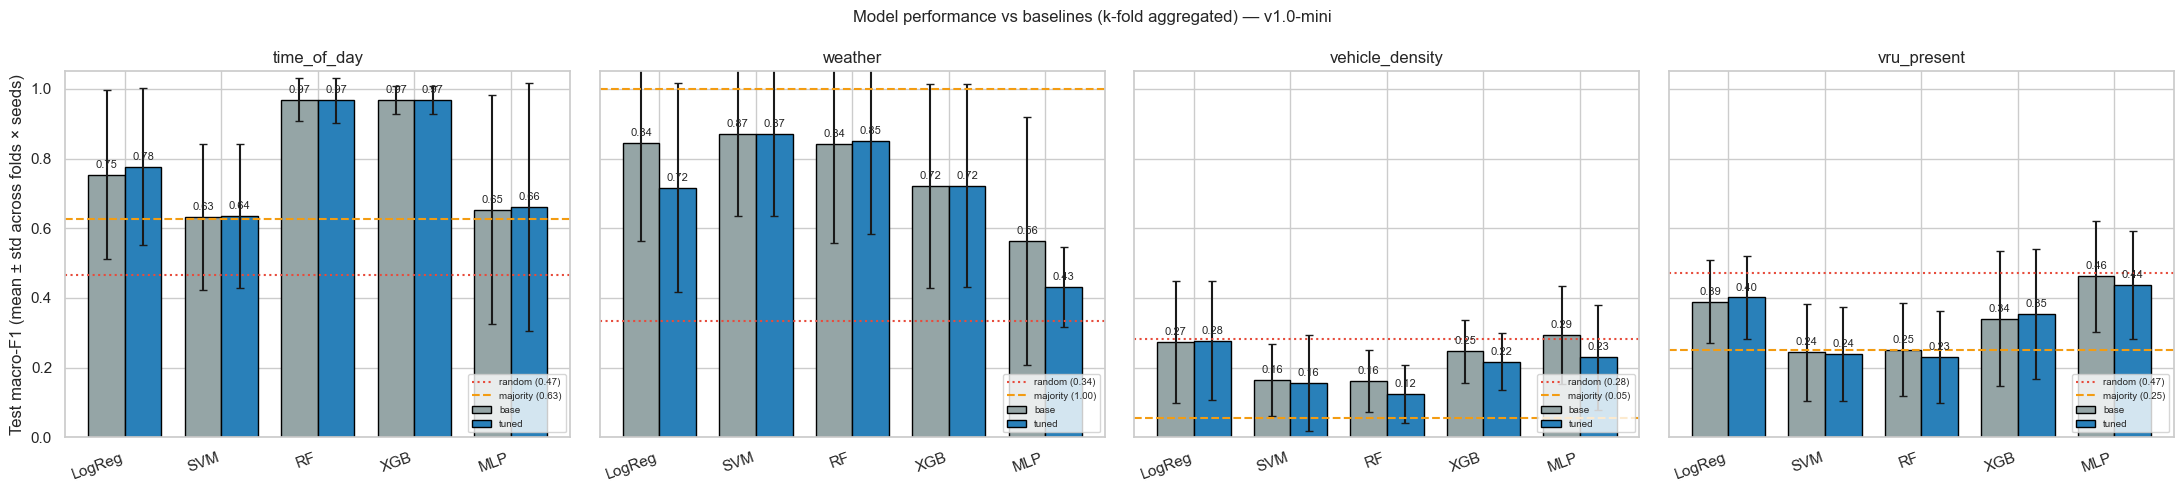

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
for ax, attr in zip(axes, ATTRIBUTES):
    sub = test_only[test_only['attribute'] == attr]

    # Per-(model, version) aggregated mean and std
    pivot = (sub.groupby(['model', 'version'])['macro_f1']
                 .agg(['mean', 'std']).reset_index())
    pivot['model'] = pd.Categorical(pivot['model'], categories=MODEL_NAMES, ordered=True)
    pivot = pivot.sort_values(['model', 'version'])

    bar_width = 0.38
    x = np.arange(len(MODEL_NAMES))
    base  = pivot[pivot['version'] == 'base'].set_index('model').reindex(MODEL_NAMES)
    tuned = pivot[pivot['version'] == 'tuned'].set_index('model').reindex(MODEL_NAMES)
    ax.bar(x - bar_width / 2, base['mean'], bar_width, yerr=base['std'],
            label='base', color='#95a5a6', capsize=3, edgecolor='black')
    ax.bar(x + bar_width / 2, tuned['mean'], bar_width, yerr=tuned['std'],
            label='tuned', color='#2980b9', capsize=3, edgecolor='black')

    # Baseline reference lines
    base_attr = df_baselines[df_baselines['attribute'] == attr]
    rand_f1 = base_attr[base_attr['baseline'] == 'random']['macro_f1'].mean()
    maj_f1  = base_attr[base_attr['baseline'] == 'majority_class']['macro_f1'].mean()
    ax.axhline(rand_f1, color='#e74c3c', linestyle=':', linewidth=1.5,
                label=f'random ({rand_f1:.2f})')
    ax.axhline(maj_f1, color='#f39c12', linestyle='--', linewidth=1.5,
                label=f'majority ({maj_f1:.2f})')

    for i, (b, t) in enumerate(zip(base['mean'], tuned['mean'])):
        ax.text(i - bar_width / 2, b + 0.02, f'{b:.2f}', ha='center', fontsize=8)
        ax.text(i + bar_width / 2, t + 0.02, f'{t:.2f}', ha='center', fontsize=8)
    ax.set_title(attr)
    ax.set_xticks(x)
    ax.set_xticklabels([DISPLAY_NAMES[m] for m in MODEL_NAMES], rotation=20, ha='right')
    ax.set_ylim(0, 1.05)
    ax.legend(loc='lower right', fontsize=7)
    if ax is axes[0]:
        ax.set_ylabel('Test macro-F1 (mean ± std across folds × seeds)')

plt.suptitle(f'Model performance vs baselines (k-fold aggregated) — {DATASET_VERSION}',
              fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'base_vs_tuned_kfold.png', bbox_inches='tight')
plt.show()

## 10. Compute Time Comparison

Fit and predict time aggregated across all folds and seeds.

In [16]:
time_df = (test_only.groupby(['model', 'version'])
                       [['fit_time_sec', 'predict_time_test_sec']]
                       .mean().round(3))
time_df.columns = ['fit_time (s)', 'predict_time_test (s)']

# Per-sample predict time (test set size varies per fold — use average)
mean_test_size = test_only.groupby(['fold'])['attribute'].count().mean() / (
    len(MODEL_NAMES) * 2 * len(SEED_LIST))
time_df['predict_time_per_sample (ms)'] = (
    time_df['predict_time_test (s)'] / mean_test_size * 1000
).round(3)

print('Mean compute time across folds, attributes & seeds:')
print(time_df)

Mean compute time across folds, attributes & seeds:
                            fit_time (s)  predict_time_test (s)  \
model              version                                        
LogisticRegression base            0.223                  0.002   
                   tuned           0.649                  0.002   
MLP                base            1.972                  0.010   
                   tuned           2.406                  0.012   
RandomForest       base            0.111                  0.014   
                   tuned           2.341                  0.026   
SVM_RBF            base            0.135                  0.057   
                   tuned           0.780                  0.054   
XGBoost            base            2.281                  0.002   
                   tuned          34.995                  0.002   

                            predict_time_per_sample (ms)  
model              version                                
LogisticRegression base  

## 11. Per-Fold Macro-F1 Distribution (visual check on fold consistency)

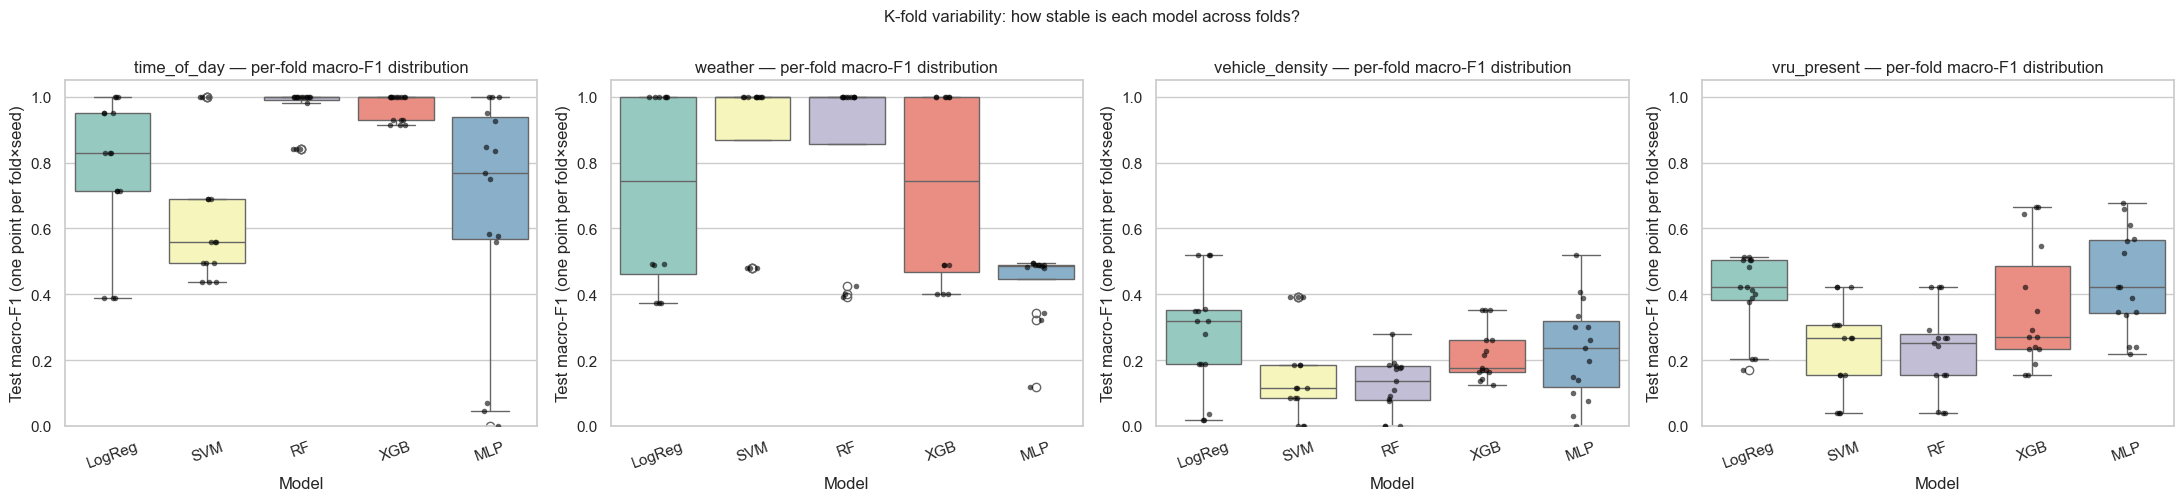

In [17]:
# For each (model, attribute), show macro-F1 distribution across folds
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, attr in zip(axes, ATTRIBUTES):
    sub = test_only[(test_only['attribute'] == attr) & (test_only['version'] == 'tuned')]
    sub['model_short'] = sub['model'].map(DISPLAY_NAMES)
    sub['model_short'] = pd.Categorical(sub['model_short'],
                                          categories=[DISPLAY_NAMES[m] for m in MODEL_NAMES],
                                          ordered=True)
    sns.boxplot(data=sub, x='model_short', y='macro_f1', ax=ax, palette='Set3')
    sns.stripplot(data=sub, x='model_short', y='macro_f1', ax=ax, color='black',
                   size=4, alpha=0.6)
    ax.set_title(f'{attr} — per-fold macro-F1 distribution')
    ax.set_xlabel('Model')
    ax.set_ylabel('Test macro-F1 (one point per fold×seed)')
    ax.tick_params(axis='x', rotation=20)
    ax.set_ylim(0, 1.05)

plt.suptitle('K-fold variability: how stable is each model across folds?',
              fontsize=12, y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / 'kfold_variability_boxplot.png', bbox_inches='tight')
plt.show()

## 12. Best Tuned Model Per Attribute (Headline Summary)

In [18]:
headline = []
for attr in ATTRIBUTES:
    sub = test_only[(test_only['attribute'] == attr) & (test_only['version'] == 'tuned')]
    by_model = sub.groupby('model')[['macro_f1', 'accuracy']].agg(['mean', 'std']).round(3)
    winner = by_model[('macro_f1', 'mean')].idxmax()
    winner_row = by_model.loc[winner]
    headline.append({
        'attribute': attr,
        'best_model': DISPLAY_NAMES[winner],
        'mean_macro_f1':    winner_row[('macro_f1', 'mean')],
        'std_macro_f1':     winner_row[('macro_f1', 'std')],
        'mean_accuracy':    winner_row[('accuracy', 'mean')],
        'std_accuracy':     winner_row[('accuracy', 'std')],
    })

df_headline = pd.DataFrame(headline)
print('=' * 80)
print('HEADLINE — best tuned model per attribute (mean ± std across folds × seeds)')
print('=' * 80)
print(df_headline.to_string(index=False))

HEADLINE — best tuned model per attribute (mean ± std across folds × seeds)
      attribute best_model  mean_macro_f1  std_macro_f1  mean_accuracy  std_accuracy
    time_of_day        XGB          0.968         0.040          0.972         0.036
        weather        SVM          0.870         0.235          0.982         0.033
vehicle_density     LogReg          0.278         0.171          0.304         0.199
    vru_present        MLP          0.437         0.154          0.512         0.172


---
## Findings & Decisions (fill in after running)

### Headline numbers (k-fold aggregated)

- `time_of_day`:     best tuned model = **_model_** with macro-F1 = **_X.XXX ± Y.YYY_** (across 5 folds × 3 seeds)
- `weather`:         best tuned model = **_model_** with macro-F1 = **_X.XXX ± Y.YYY_**
- `vehicle_density`: best tuned model = **_model_** with macro-F1 = **_X.XXX ± Y.YYY_**
- `vru_present`:     best tuned model = **_model_** with macro-F1 = **_X.XXX ± Y.YYY_**

### Statistical robustness

- Each headline number is based on **15 measurements** (5 folds × 3 seeds), enabling proper Wilcoxon paired tests downstream.
- Standard deviations across folds quantify the **dataset-level uncertainty**: how much would the result change with a different test set?
- Per-fold variability captured in §11 boxplots reveals which models are stable vs unstable across folds.

### Comparison to single-split version

| Aspect | Single split | K-fold (this version) |
|---|---|---|
| Test sample size | 81 (fixed) | ~400 across 5 folds combined |
| `weather` rain coverage | 0 in test | 40 spread across folds |
| `vehicle_density` high coverage | 1 in test | 135 across folds |
| Per-class metrics | Unreliable | Robust aggregate |
| Statistical power | 15 obs | 75 obs per pairwise test |

### Implications for next phase

- Notebook 07 (feature ablation): also adopts k-fold, 1500 ablation fits
- Notebook 08a (headline tables): aggregates k-fold metrics into Table 7/8/9 formats
- Notebook 08b (visual + stats): per-fold ROC, statistical tests with higher power
- Notebook 08c (deep analysis): per-fold importance, with scaling discussion to v1.0-trainval
